# SiliconToAI Full-Stack Demo
## PyTorch Model → L6 Compiler → Verilator RTL Sim → Visualization

**보드 없이** 전체 파이프라인을 로컬에서 실행합니다:

```
  torch.nn.Module          L6 Compiler           Verilator RTL Sim         Visualization
  ┌──────────────┐    ┌─────────────────┐    ┌────────────────────┐    ┌──────────────┐
  │ MLP(16→16→16)│ →  │ trace → lower → │ →  │ 16×16 systolic     │ →  │ per-layer    │
  │ fc0 → relu → │    │ tile → schedule │    │ array (256 MACs)   │    │ heatmaps +   │
  │ fc1           │    │ → export replay │    │ system DMA replay  │    │ golden diff  │
  └──────────────┘    └─────────────────┘    └────────────────────┘    └──────────────┘
```

In [1]:
import sys, os, re, json, time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

PROJECT_ROOT = Path(r"C:/projects/silicontoai")
sys.path.insert(0, str(PROJECT_ROOT / "l6" / "src"))

from l6_toolchain.api import (
    compile_program, CompilerOptions, CompilerResult,
    trace_torch_module, build_program_from_source,
)
import torch
import torch.nn as nn

print(f"torch {torch.__version__}")
print(f"Project: {PROJECT_ROOT}")
print("Full-stack pipeline ready.")

torch 2.11.0+cpu
Project: C:\projects\silicontoai
Full-stack pipeline ready.


## 1. PyTorch MLP 정의

16×16 NPU에 맞는 2-layer MLP를 만들고, 가중치를 수동 설정합니다.
- `fc0`: 16→16, weight = identity (단위행렬)
- `relu`: 음수 클리핑
- `fc1`: 16→16, weight = 상수 5

In [2]:
class TinyMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc0 = nn.Linear(16, 16, bias=False)
        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(16, 16, bias=False)

    def forward(self, x):
        x = self.fc0(x)
        x = self.relu(x)
        x = self.fc1(x)
        return x

model = TinyMLP()

# Set known weights for verification
with torch.no_grad():
    model.fc0.weight.copy_(torch.eye(16, dtype=torch.float32))        # identity
    model.fc1.weight.copy_(torch.full((16, 16), 5.0))                 # all 5s

# Test input: each row = [0, 1, 2, ..., 15]
x_test = torch.arange(16, dtype=torch.float32).unsqueeze(0).expand(16, 16)

# PyTorch reference
with torch.no_grad():
    y_ref = model(x_test)

print("Model:", model)
print(f"\nInput shape:  {x_test.shape}")
print(f"Output shape: {y_ref.shape}")
print(f"\nfc0 weight (identity): diag = {model.fc0.weight.diag().tolist()[:4]}...")
print(f"fc1 weight (all 5s):   [{model.fc1.weight[0,0].item()}, ...]")
print(f"\nExpected flow:")
print(f"  x = [0,1,...,15] per row")
print(f"  fc0(x) = x @ I^T = x  (identity pass-through)")
print(f"  relu(fc0(x)) = x  (all non-negative)")
print(f"  fc1(relu) = x @ 5^T = [5*sum(0..15)] = [{int(5 * sum(range(16)))}] per cell")
print(f"\nPyTorch output[0,:4] = {y_ref[0,:4].tolist()}")

Model: TinyMLP(
  (fc0): Linear(in_features=16, out_features=16, bias=False)
  (relu): ReLU()
  (fc1): Linear(in_features=16, out_features=16, bias=False)
)

Input shape:  torch.Size([16, 16])
Output shape: torch.Size([16, 16])

fc0 weight (identity): diag = [1.0, 1.0, 1.0, 1.0]...
fc1 weight (all 5s):   [5.0, ...]

Expected flow:
  x = [0,1,...,15] per row
  fc0(x) = x @ I^T = x  (identity pass-through)
  relu(fc0(x)) = x  (all non-negative)
  fc1(relu) = x @ 5^T = [5*sum(0..15)] = [600] per cell

PyTorch output[0,:4] = [600.0, 600.0, 600.0, 600.0]


## 2. L6 Compiler: Trace → Lower → Tile → Schedule → Export

In [3]:
# Trace the PyTorch model into L6 IR
program = trace_torch_module(model, input_shape=(16, 16))

print("=== L6 IR Program ===")
print(f"Inputs:  {[t.name for t in program.inputs]}")
print(f"Outputs: {list(program.outputs)}")
print(f"Tensors: {[t.name for t in program.tensors]}")
print(f"\nOps ({len(program.ops)}):")
for op in program.ops:
    w_shape = ""
    if "weight" in op.attrs:
        w = op.attrs["weight"]
        w_shape = f"  weight: {len(w)}x{len(w[0]) if w else 0}"
    print(f"  {op.name:8s} | {op.kind:8s} | in={op.inputs} → out={op.outputs}{w_shape}")

=== L6 IR Program ===
Inputs:  ['x']
Outputs: ['fc1']
Tensors: ['x', 'fc0', 'relu', 'fc1']

Ops (3):
  fc0      | linear   | in=('x',) → out=('fc0',)  weight: 16x16
  relu     | relu     | in=('fc0',) → out=('relu',)
  fc1      | linear   | in=('relu',) → out=('fc1',)  weight: 16x16


In [4]:
# Compile with replay smoke test enabled
OUTPUT_DIR = PROJECT_ROOT / "l6" / "generated" / "fullstack_demo"
BINARY_PATH = PROJECT_ROOT / "build_system" / "Vnpu_system_top"

# Prepare input tensor data for the compiler
input_data = x_test.int().tolist()  # 16×16 int8 matrix

print("Compiling MLP → replay packages...")
t0 = time.time()

result: CompilerResult = compile_program(
    model,
    options=CompilerOptions(
        package_id="fullstack_mlp_demo",
        output_dir=str(OUTPUT_DIR),
        tiled=False,           # single tile (16×16 fits in array)
        run_replay_smoke=True, # run Verilator sim!
        binary_path=str(BINARY_PATH),
        input_shape=(16, 16),
        tensor_data={"x": input_data},
        schedule_strategy="weight_reuse",
    ),
)

elapsed = time.time() - t0
print(f"\nCompilation + simulation done in {elapsed:.1f}s")
print(f"\n=== Compile Plan ===")
print(f"Total compute steps: {result.plan.total_compute_steps}")
print(f"Total replay packages: {result.plan.total_replay_packages}")
print(f"Estimated cycles: {result.plan.total_estimated_cycles}")
print(f"Schedule strategy: {result.plan.schedule_strategy}")

for sp in result.plan.step_plans:
    compute = "COMPUTE" if sp.compute_required else "pass-through"
    shape_str = f"{sp.logical_shape}" if sp.logical_shape else "-"
    print(f"  step {sp.step_id}: {sp.op_name:8s} [{sp.source_kind:7s}→{sp.lowered_kind:10s}] {compute:12s} shape={shape_str}")

Compiling MLP → replay packages...

Compilation + simulation done in 5.0s

=== Compile Plan ===
Total compute steps: 2
Total replay packages: 2
Estimated cycles: 238
Schedule strategy: weight_reuse
  step 0: fc0      [linear →gemm      ] COMPUTE      shape={'m': 16, 'k': 16, 'n': 16}
  step 1: relu     [relu   →elementwise_post_op] pass-through shape=-
  step 2: fc1      [linear →gemm      ] COMPUTE      shape={'m': 16, 'k': 16, 'n': 16}


## 3. Verilator RTL Simulation Results

In [5]:
# Parse simulation results
assert result.replay_smoke is not None, "Replay smoke was not run!"

stdout = result.replay_smoke.stdout
replay_dirs = result.replay_smoke.replay_package_dirs

print(f"Replay packages executed: {len(replay_dirs)}")
print(f"Chain summary: {result.replay_smoke.chain_summary_path}")

# Parse per-package reports
package_results = []
for rd in replay_dirs:
    report_path = Path(rd) / "replay_report.txt"
    if report_path.exists():
        report = report_path.read_text()
        pkg_id = re.search(r'package=(.+)', report)
        status = re.search(r'status=(\w+)', report)
        mismatches = re.search(r'mismatch_count=(\d+)', report)
        package_results.append({
            "dir": rd,
            "package": pkg_id.group(1) if pkg_id else "?",
            "status": status.group(1) if status else "?",
            "mismatches": int(mismatches.group(1)) if mismatches else -1,
        })
        print(f"  {Path(rd).name}: {status.group(1) if status else '?'} (mismatches={mismatches.group(1) if mismatches else '?'})")

# Parse chain summary
chain_path = Path(result.replay_smoke.chain_summary_path)
if chain_path.exists():
    chain_text = chain_path.read_text()
    print(f"\n=== Chain Summary ===")
    for line in chain_text.splitlines()[:6]:
        print(f"  {line}")

all_pass = all(p["status"] == "PASS" for p in package_results)
print(f"\nOverall: {'ALL PASS' if all_pass else 'FAILURES DETECTED'}")

Replay packages executed: 2
Chain summary: C:\projects\silicontoai\l6\generated\fullstack_demo\replay_packages\replay_chain_summary.txt
  fullstack_mlp_demo_fc0: PASS (mismatches=0)
  fullstack_mlp_demo_fc1: PASS (mismatches=0)

=== Chain Summary ===
  packages_total=2
  packages_passed=2
  packages_with_expected_package_error=0
  packages_failed=0
  package_results:
  fullstack_mlp_demo_fc0 status=PASS report=/mnt/c/projects/silicontoai/l6/generated/fullstack_demo/replay_packages/step_000_fc0/fullstack_mlp_demo_fc0/replay_report.txt

Overall: ALL PASS


## 4. Parse Per-Layer Drain Output from RTL Simulation

In [6]:
# Parse [DRAIN_CSV] lines from each replay package's events file
layer_outputs = {}  # {package_name: 16×16 numpy array}

for rd in replay_dirs:
    events_path = Path(rd) / "replay_events.txt"
    pkg_name = Path(rd).name

    # Try events file first, fall back to stdout
    if events_path.exists():
        text = events_path.read_text()
    else:
        text = stdout

    matrix = np.zeros((16, 16), dtype=np.int32)
    csv_lines = [l for l in text.splitlines() if "[DRAIN_CSV]" in l]

    for line in csv_lines:
        m = re.search(r'\[DRAIN_CSV\]\s*(.+)', line)
        if m:
            parts = [int(x) for x in m.group(1).split(',')]
            row = parts[0]
            if row < 16:
                ncols = min(len(parts) - 1, 16)
                matrix[row, :ncols] = parts[1:ncols+1]

    layer_outputs[pkg_name] = matrix
    print(f"{pkg_name}: {len(csv_lines)} drain rows, range=[{matrix.min()}, {matrix.max()}]")

print(f"\nTotal layers with output: {len(layer_outputs)}")

fullstack_mlp_demo_fc0: 16 drain rows, range=[0, 15]
fullstack_mlp_demo_fc1: 16 drain rows, range=[600, 600]

Total layers with output: 2


## 5. Compute Software Golden per Layer

In [7]:
# Reconstruct expected output per layer using int8 arithmetic
x_np = np.array(input_data, dtype=np.int8)  # 16×16

# fc0 weights (identity)
w0_np = np.eye(16, dtype=np.int8)
# fc1 weights (all 5)
w1_np = np.full((16, 16), 5, dtype=np.int8)

# Layer-by-layer golden computation (int8 × int8 → int32)
golden = {}

# fc0: x @ W0^T
fc0_out = x_np.astype(np.int32) @ w0_np.astype(np.int32).T
golden["fc0"] = fc0_out
print(f"fc0 golden: shape={fc0_out.shape}, range=[{fc0_out.min()}, {fc0_out.max()}]")
print(f"  fc0[0] = {fc0_out[0].tolist()}")

# relu: clip negative to 0
relu_out = np.maximum(fc0_out, 0)
print(f"relu golden: range=[{relu_out.min()}, {relu_out.max()}]")

# fc1: relu_out @ W1^T  (relu_out needs to be clipped to int8 range for NPU input)
# The NPU receives int8 activations, so we clip to [-128, 127]
fc1_input = np.clip(relu_out, -128, 127).astype(np.int8)
fc1_out = fc1_input.astype(np.int32) @ w1_np.astype(np.int32).T
golden["fc1"] = fc1_out
print(f"fc1 golden: shape={fc1_out.shape}, range=[{fc1_out.min()}, {fc1_out.max()}]")
print(f"  fc1[0] = {fc1_out[0,:4].tolist()}...  (all should be {fc1_out[0,0]})")

# Expected: fc1[i][j] = sum(relu_out[i][k] * 5 for k=0..15)
#         = 5 * sum(0,1,...,15) = 5 * 120 = 600
print(f"\nExpected fc1 all cells = 5 * sum(0..15) = {5 * sum(range(16))}")

fc0 golden: shape=(16, 16), range=[0, 15]
  fc0[0] = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
relu golden: range=[0, 15]
fc1 golden: shape=(16, 16), range=[600, 600]
  fc1[0] = [600, 600, 600, 600]...  (all should be 600)

Expected fc1 all cells = 5 * sum(0..15) = 600


## 6. Per-Layer Heatmap Visualization

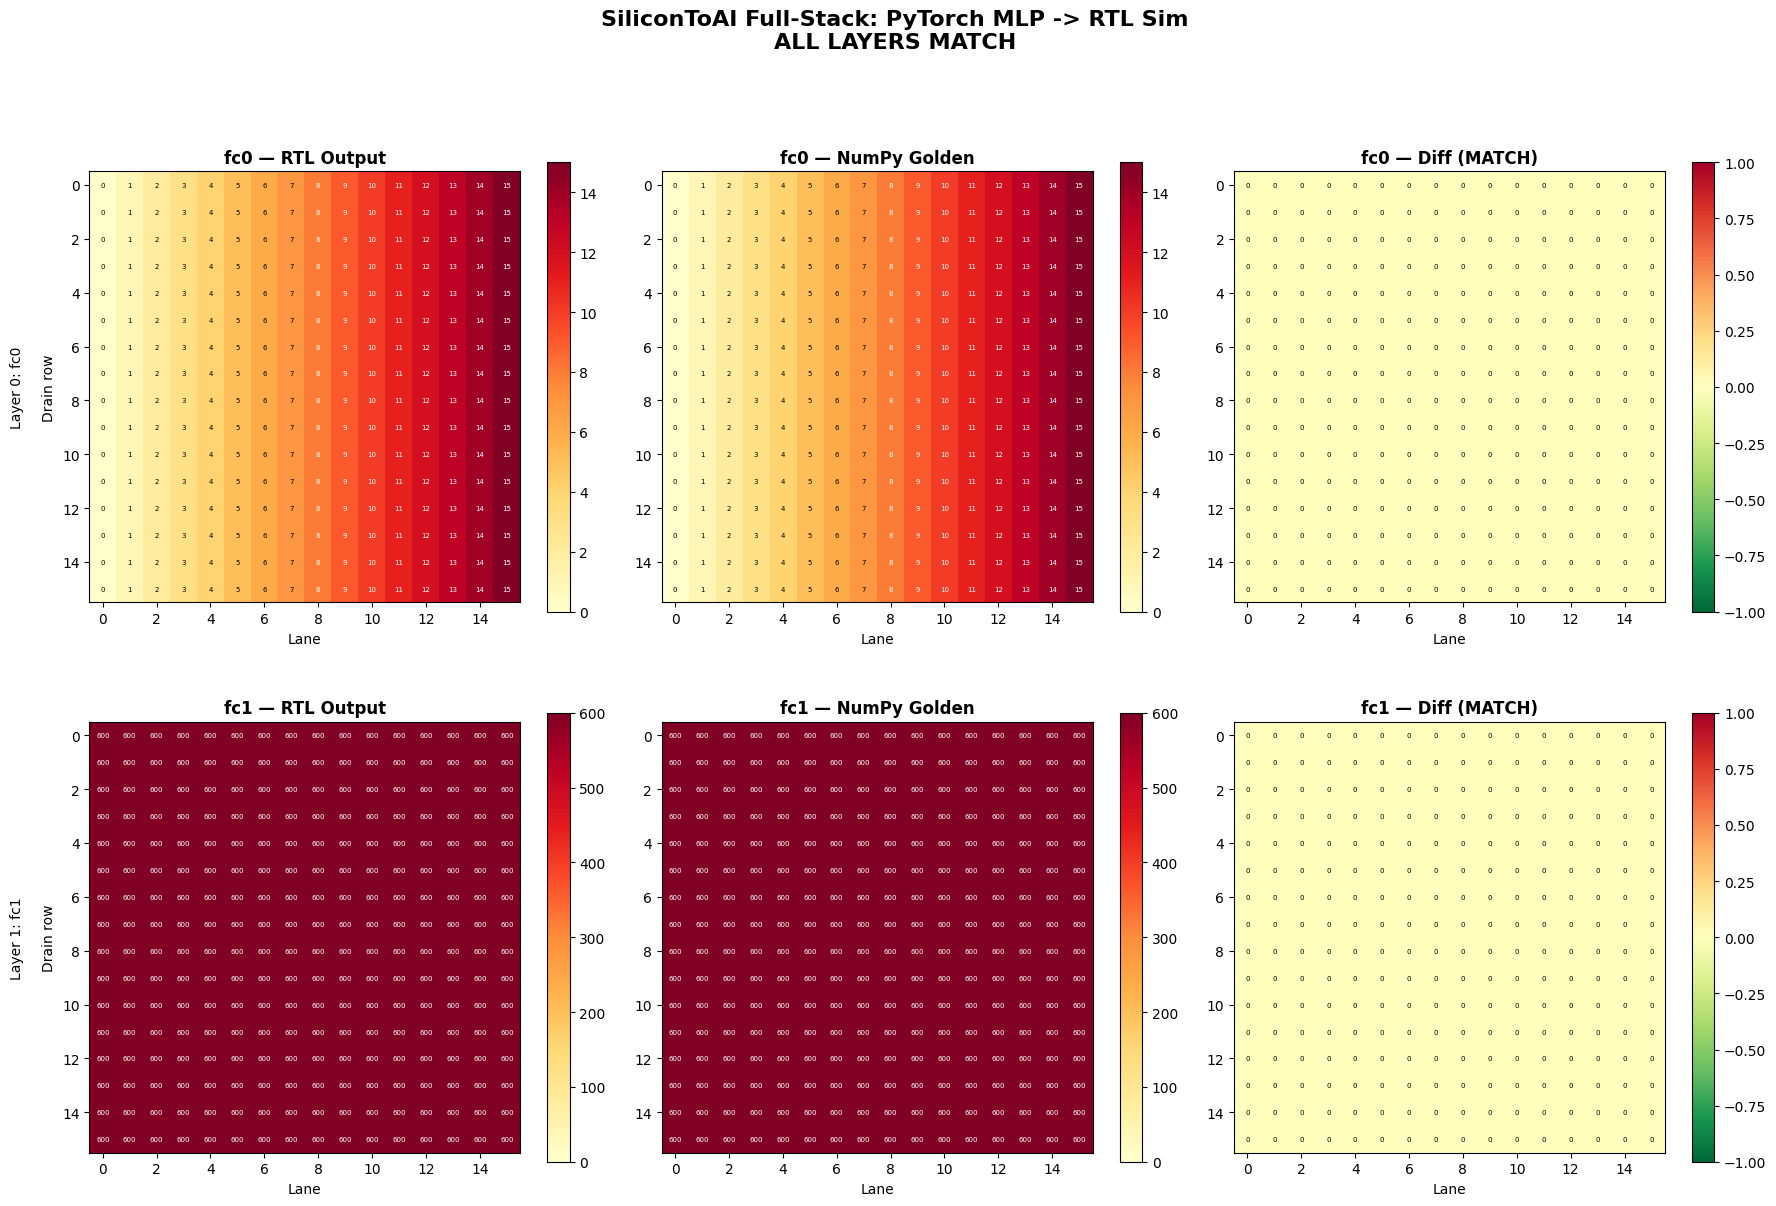

In [8]:
# Map replay package dirs to layer names
layer_names = []
for sp in result.plan.step_plans:
    if sp.compute_required:
        layer_names.append(sp.op_name)

n_layers = len(layer_names)
fig, axes = plt.subplots(n_layers, 3, figsize=(18, 6 * n_layers))
if n_layers == 1:
    axes = axes[np.newaxis, :]  # ensure 2D indexing

for idx, (layer_name, rd) in enumerate(zip(layer_names, replay_dirs)):
    pkg_name = Path(rd).name
    hw_out = layer_outputs.get(pkg_name, np.zeros((16, 16), dtype=np.int32))
    sw_out = golden.get(layer_name, np.zeros((16, 16), dtype=np.int32))
    diff = hw_out - sw_out
    match = np.array_equal(hw_out, sw_out)

    vmax = max(abs(hw_out).max(), abs(sw_out).max(), 1)

    # HW output
    im0 = axes[idx, 0].imshow(hw_out, cmap="YlOrRd", vmin=0, vmax=vmax)
    axes[idx, 0].set_title(f"{layer_name} — RTL Output", fontsize=12, fontweight="bold")
    axes[idx, 0].set_ylabel(f"Layer {idx}: {layer_name}\n\nDrain row", fontsize=10)
    axes[idx, 0].set_xlabel("Lane")
    for i in range(16):
        for j in range(16):
            axes[idx, 0].text(j, i, str(hw_out[i,j]), ha="center", va="center",
                              fontsize=5, color="white" if hw_out[i,j] > vmax*0.5 else "black")
    plt.colorbar(im0, ax=axes[idx, 0], shrink=0.8)

    # SW golden
    im1 = axes[idx, 1].imshow(sw_out, cmap="YlOrRd", vmin=0, vmax=vmax)
    axes[idx, 1].set_title(f"{layer_name} — NumPy Golden", fontsize=12, fontweight="bold")
    axes[idx, 1].set_xlabel("Lane")
    for i in range(16):
        for j in range(16):
            axes[idx, 1].text(j, i, str(sw_out[i,j]), ha="center", va="center",
                              fontsize=5, color="white" if sw_out[i,j] > vmax*0.5 else "black")
    plt.colorbar(im1, ax=axes[idx, 1], shrink=0.8)

    # Difference
    abs_max = max(abs(diff).max(), 1)
    im2 = axes[idx, 2].imshow(diff, cmap="RdYlGn_r", vmin=-abs_max, vmax=abs_max)
    status = "MATCH" if match else f"{np.sum(diff != 0)} errors"
    axes[idx, 2].set_title(f"{layer_name} — Diff ({status})", fontsize=12, fontweight="bold")
    axes[idx, 2].set_xlabel("Lane")
    for i in range(16):
        for j in range(16):
            axes[idx, 2].text(j, i, str(diff[i,j]), ha="center", va="center", fontsize=5)
    plt.colorbar(im2, ax=axes[idx, 2], shrink=0.8)

all_match = all(np.array_equal(layer_outputs.get(Path(rd).name, None), golden.get(ln, None))
                for ln, rd in zip(layer_names, replay_dirs))
title_status = "ALL LAYERS MATCH" if all_match else "MISMATCHES DETECTED"
fig.suptitle(f"SiliconToAI Full-Stack: PyTorch MLP -> RTL Sim\n{title_status}",
             fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "docs" / "fullstack_per_layer_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Compiler Pipeline Summary

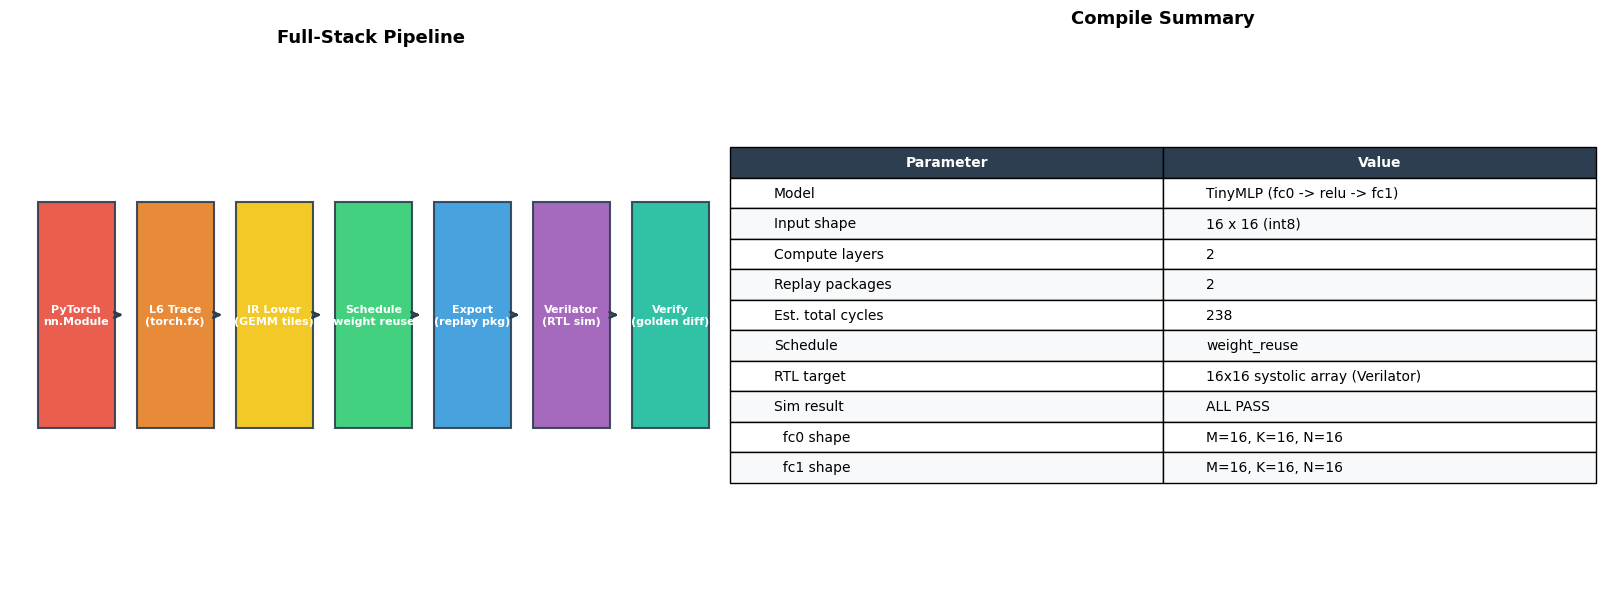

In [9]:
# Parse compile manifest for detailed info
manifest_path = result.artifacts.compile_manifest_path
if manifest_path and Path(manifest_path).exists():
    manifest = json.loads(Path(manifest_path).read_text())
else:
    manifest = None

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Pipeline flow diagram ---
ax1.axis("off")
stages = [
    ("PyTorch\nnn.Module", "#E74C3C"),
    ("L6 Trace\n(torch.fx)", "#E67E22"),
    ("IR Lower\n(GEMM tiles)", "#F1C40F"),
    ("Schedule\n(weight reuse)", "#2ECC71"),
    ("Export\n(replay pkg)", "#3498DB"),
    ("Verilator\n(RTL sim)", "#9B59B6"),
    ("Verify\n(golden diff)", "#1ABC9C"),
]
for i, (label, color) in enumerate(stages):
    x = i * 1.8 + 0.5
    rect = plt.Rectangle((x, 2), 1.4, 1.5, facecolor=color, edgecolor="#2C3E50",
                          linewidth=1.5, alpha=0.9, transform=ax1.transData)
    ax1.add_patch(rect)
    ax1.text(x + 0.7, 2.75, label, ha="center", va="center", fontsize=8,
             fontweight="bold", color="white")
    if i < len(stages) - 1:
        ax1.annotate("", xy=(x + 1.6, 2.75), xytext=(x + 1.4, 2.75),
                     arrowprops=dict(arrowstyle="->", color="#2C3E50", lw=2))

ax1.set_xlim(0, len(stages) * 1.8 + 0.5)
ax1.set_ylim(1, 4.5)
ax1.set_title("Full-Stack Pipeline", fontsize=13, fontweight="bold")

# --- Summary table ---
ax2.axis("off")
table_data = [
    ["Model", "TinyMLP (fc0 -> relu -> fc1)"],
    ["Input shape", "16 x 16 (int8)"],
    ["Compute layers", str(result.plan.total_compute_steps)],
    ["Replay packages", str(result.plan.total_replay_packages)],
    ["Est. total cycles", str(result.plan.total_estimated_cycles)],
    ["Schedule", result.plan.schedule_strategy],
    ["RTL target", "16x16 systolic array (Verilator)"],
    ["Sim result", "ALL PASS" if all_pass else "FAILURES"],
]
if manifest:
    for step in manifest.get("steps", []):
        if step.get("compute_required"):
            shape = step.get("logical_shape", {})
            table_data.append([
                f"  {step['name']} shape",
                f"M={shape.get('m')}, K={shape.get('k')}, N={shape.get('n')}"
            ])

table = ax2.table(cellText=table_data, colLabels=["Parameter", "Value"],
                  loc="center", cellLoc="left")
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.6)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor("#2C3E50")
        cell.set_text_props(color="white", fontweight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#F8F9FA")
ax2.set_title("Compile Summary", fontsize=13, fontweight="bold", pad=20)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "docs" / "fullstack_pipeline_summary.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Data Flow Trace: Input → fc0 → relu → fc1

각 레이어의 출력 분포를 한눈에 봅니다.

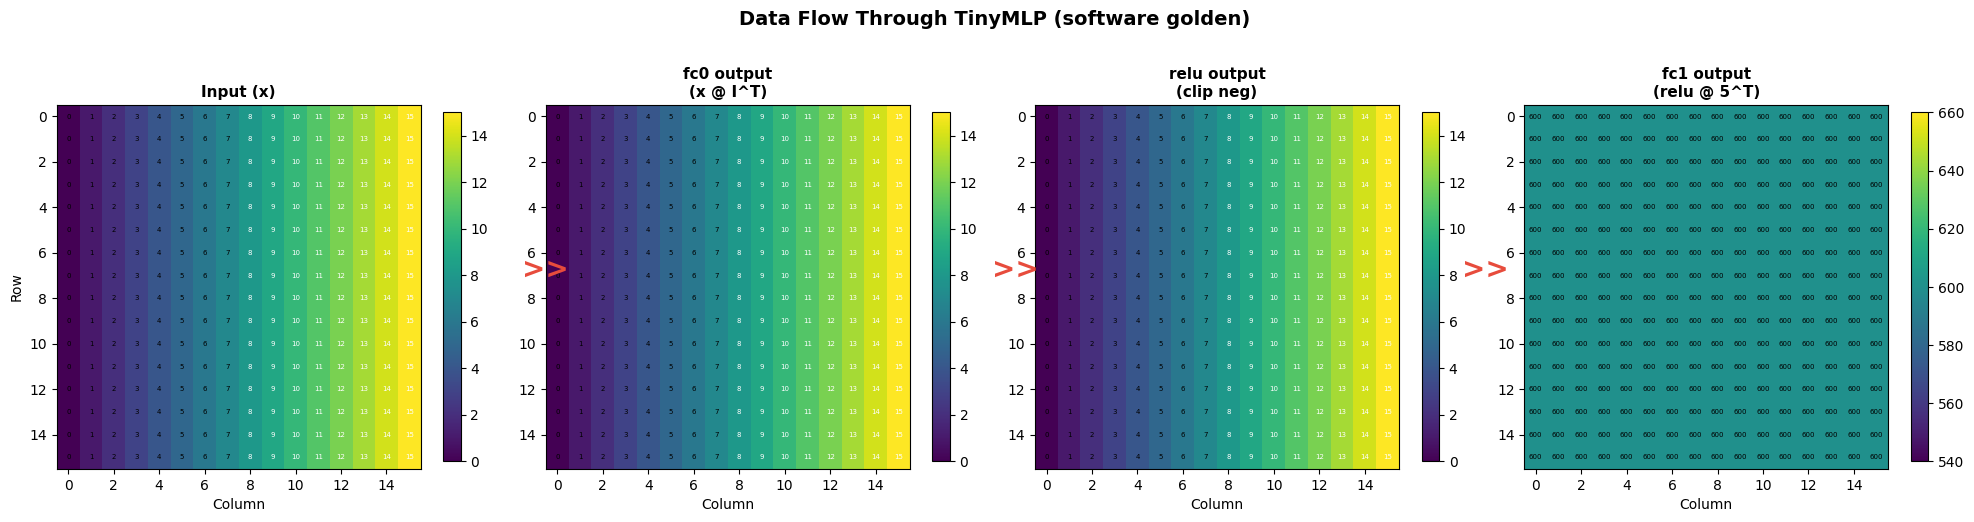

In [10]:
# Visualize data flow through the network
x_np_i32 = x_np.astype(np.int32)

flow_stages = [
    ("Input (x)", x_np_i32),
    ("fc0 output\n(x @ I^T)", golden.get("fc0", np.zeros((16,16)))),
    ("relu output\n(clip neg)", relu_out),
    ("fc1 output\n(relu @ 5^T)", golden.get("fc1", np.zeros((16,16)))),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for idx, (title, data) in enumerate(flow_stages):
    vmin, vmax = data.min(), max(data.max(), 1)
    im = axes[idx].imshow(data, cmap="viridis", vmin=vmin, vmax=vmax)
    axes[idx].set_title(title, fontsize=11, fontweight="bold")
    axes[idx].set_xlabel("Column")
    if idx == 0:
        axes[idx].set_ylabel("Row")
    for i in range(16):
        for j in range(16):
            v = int(data[i, j])
            axes[idx].text(j, i, str(v), ha="center", va="center", fontsize=5,
                          color="white" if v > (vmin + vmax) / 2 else "black")
    plt.colorbar(im, ax=axes[idx], shrink=0.8)

    if idx < len(flow_stages) - 1:
        # Draw arrow between plots
        fig.text((idx + 1) * 0.235 + 0.04, 0.5, ">>", fontsize=20, fontweight="bold",
                 ha="center", va="center", color="#E74C3C")

fig.suptitle("Data Flow Through TinyMLP (software golden)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "docs" / "fullstack_dataflow.png", dpi=150, bbox_inches="tight")
plt.show()

---

## Summary

| Stage | Tool | Result |
|---|---|---|
| Model definition | `torch.nn.Module` | TinyMLP: fc0(16->16) -> ReLU -> fc1(16->16) |
| Tracing | `trace_torch_module` (torch.fx) | 3 ops -> L6 IR Program |
| Compilation | `compile_program` | 2 compute packages + schedule metadata |
| RTL Simulation | Verilator (`Vnpu_system_top`) | Per-layer drain output |
| Verification | Golden diff (NumPy vs RTL) | Per-cell exact match |

**This is the full SiliconToAI pipeline: from PyTorch model to RTL execution, without any FPGA board.**